# Single-storm tropical-cyclone intensity verification

This notebook reads ATCF A-deck forecasts and B-deck best-track data from the repository's `data/adeck` and `data/bdeck` directories. It verifies `VMAX`, `PMIN`, `RMW`, `R34`, `R50`, or `R64` using either strict or lead-dependent relaxed sampling.

In `strict` mode, a cycle is retained only when the B-deck contains `cycle + lead_time` and every requested model and the best track have a valid selected metric at every verified lead. In `relaxed` mode, complete common cases are selected independently at each lead and the returned `n_cases` reports the changing sample size. Errors are forecast minus best track. To match the requested `T = int(lead_time / hh)`, the verified leads are `0, hh, ..., (T-1) * hh`. Correlation is the Pearson correlation over all valid forecast/best-track pairs for each model.

For wind-radius metrics, an `AAA` record uses its single radius. Other wind-code records use the arithmetic mean of the four quadrant radii; explicit zero radii are included. Intensity is in kt (`VMAX`), pressure in hPa (`PMIN`), and radii in nautical miles (`RMW`, `R34`, `R50`, and `R64`).

In [1]:
from __future__ import annotations

from typing import Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np

try:
    from src import mod_abdeck as abdeck
    from src import mod_verification as verif
except ModuleNotFoundError as exc:
    if exc.name != "src":
        raise
    import mod_abdeck as abdeck
    import mod_verification as verif

## Find the first B-deck threshold period

For `VMAX`, `RMW`, `R34`, `R50`, and `R64`, a cycle qualifies when the metric is strictly greater than the threshold. For `PMIN`, the comparison is reversed and a cycle qualifies when pressure is strictly less than the threshold. The returned interval is `[start_cycle, end_cycle)`, so `end_cycle` is the first non-qualifying cycle and is not part of the qualifying period.

In [10]:
threshold_metric = "VMAX"
threshold_value = 95
threshold_start_cycle, threshold_end_cycle = abdeck.find_bdeck_threshold_period(
    storm_id="17E",
    year="2026",
    metric=threshold_metric,
    threshold=threshold_value,
)

qualifying_operator = "<" if threshold_metric == "PMIN" else ">"
ending_operator = ">=" if threshold_metric == "PMIN" else "<="
print(
    f"First {threshold_metric} {qualifying_operator} {threshold_value} cycle:",
    threshold_start_cycle,
)
print(
    f"First following {threshold_metric} {ending_operator} {threshold_value} cycle "
    "(exclusive end):",
    threshold_end_cycle,
)

# For PMIN, try threshold_metric="PMIN" and threshold_value=970.
# The function will select PMIN < 970 and stop at the first PMIN >= 970.

First VMAX > 95 cycle: 2026092206
First following VMAX <= 95 cycle (exclusive end): 2026092906


In [3]:
def plot_verification_errors(
    errs_abs: Sequence[Sequence[float]],
    errs_bias: Sequence[Sequence[float]],
    models: Sequence[str],
    hh: int,
    metric: str,
    *,
    n_cases: Sequence[int] | None = None,
    figsize: Tuple[float, float] = (12, 4.5),
) -> Tuple[plt.Figure, np.ndarray]:
    if len(models) != len(errs_abs) or len(models) != len(errs_bias):
        raise ValueError("models, errs_abs, and errs_bias must have equal lengths.")
    if not models:
        raise ValueError("At least one model is required.")
    if isinstance(hh, bool) or not isinstance(hh, int) or hh <= 0:
        raise ValueError("hh must be a positive integer.")

    n_leads = len(errs_abs[0])
    if any(len(values) != n_leads for values in list(errs_abs) + list(errs_bias)):
        raise ValueError("All error series must have the same number of leads.")
    if n_cases is not None and len(n_cases) != n_leads:
        raise ValueError("n_cases must have one value per forecast lead.")
    lead_hours = np.arange(n_leads) * hh
    units = {
        "VMAX": "kt",
        "PMIN": "hPa",
        "RMW": "n mi",
        "R34": "n mi",
        "R50": "n mi",
        "R64": "n mi",
    }
    metric = str(metric).strip().upper()
    unit = units.get(metric, "metric units")

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True)
    for model, mae, bias in zip(models, errs_abs, errs_bias):
        axes[0].plot(lead_hours, mae, marker="o", label=model)
        axes[1].plot(lead_hours, bias, marker="o", label=model)

    axes[0].set_title(f"{metric} mean absolute error")
    axes[1].set_title(f"{metric} bias (forecast - best track)")
    axes[0].set_ylabel(unit)
    axes[1].axhline(0.0, color="black", linewidth=0.8)
    for axis in axes:
        if n_cases is None:
            axis.set_xticks([0, 6, 12, 18, 24, 36, 48, 72, 96, 120])
            axis.set_xlim(0, 120)
        else:
            axis.set_xticks(lead_hours)
            axis.set_xticklabels(
                [f"{lead}\n{count}" for lead, count in zip(lead_hours, n_cases)],
                fontsize=7,
            )
            axis.set_xlim(lead_hours[0] - hh / 2, lead_hours[-1] + hh / 2)
        axis.set_xlabel("Forecast lead time (h)")
        axis.grid(True, alpha=0.3)
        axis.legend()
    fig.tight_layout()
    return fig, axes

## Check a single storm verification

Choose a storm, time interval, model identifiers, and sampling mode. Set `end_cycle=None` to use every common cycle on or after `start_cycle`. In relaxed mode, the second row of each x-axis tick label is the number of verified cases.

Cycles represented in errs (N): 12
Lead count (T): 20
Verified cases by lead: {0: 12, 6: 12, 12: 12, 18: 12, 24: 12, 30: 12, 36: 12, 42: 12, 48: 12, 54: 12, 60: 12, 66: 12, 72: 12, 78: 12, 84: 12, 90: 12, 96: 12, 102: 12, 108: 12, 114: 12}
Correlations: {'HWRF': 0.7260372534014379, 'HFSA': 0.6946278019854335}


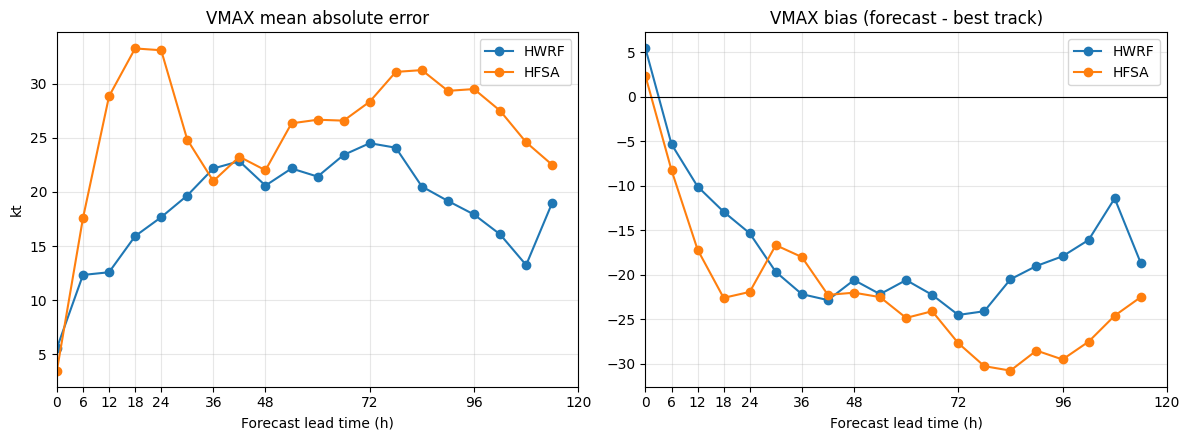

In [4]:
# Example (edit these values for the desired storm):
models = ["HWRF", "HFSA"]
hh = 6
sample_mode = "strict"  # Change to "relaxed" for per-lead samples.
errs, errs_abs, errs_bias, corr, n_cases = verif.verify_single_storm(
    storm_id="17E",
    year="2026",
    start_cycle="2026092206",
    end_cycle="2026092500",
    models=models,
    hh=hh,
    lead_time=120,
    metric="VMAX",
    sample_mode=sample_mode,
)

print("Cycles represented in errs (N):", errs[0].shape[0])
print("Lead count (T):", errs[0].shape[1])
lead_hours = (np.arange(len(n_cases)) * hh).tolist()
print("Verified cases by lead:", dict(zip(lead_hours, n_cases)))
print("Correlations:", dict(zip(models, corr)))
fig, axes = plot_verification_errors(
    errs_abs,
    errs_bias,
    models,
    hh,
    "VMAX",
    n_cases=n_cases if sample_mode == "relaxed" else None,
)